# Diabetes Risk Prediction Web Application

## Project objective

The goal of this project is to train a machine-learning model using the Pima Indians Diabetes dataset and deploy it as an interactive Flask web application.

The application will accept eight patient-related measurements and return:

- A predicted outcome class
- An estimated probability from the model

This application is an educational demonstration and is not intended to diagnose diabetes or replace professional medical evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/diabetes.csv")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Inspect column names, data types, and missing values

df.info()

print("\nMissing values:")
display(df.isnull().sum())

print("\nTarget distribution:")
display(df["Outcome"].value_counts())
display(df["Outcome"].value_counts(normalize=True).round(3))

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Missing values:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Target distribution:


Outcome
0    500
1    268
Name: count, dtype: int64

Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

## Initial observations

The dataset contains 768 observations and nine variables. Eight variables will be used as predictors, while `Outcome` is the binary target.

There are no missing values formally recorded as `NaN`. The target is moderately imbalanced:

- Outcome 0: 500 observations (65.1%)
- Outcome 1: 268 observations (34.9%)

Because of this imbalance, model performance should not be evaluated using accuracy alone. Recall, precision, F1-score, ROC-AUC, and the confusion matrix will also be considered.

In [4]:
# Check for duplicate observations

print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [5]:
# Count zero values in each predictor

predictor_columns = df.columns.drop("Outcome")

zero_counts = pd.DataFrame({
    "zero_count": (df[predictor_columns] == 0).sum(),
    "zero_percentage": ((df[predictor_columns] == 0).mean() * 100).round(1)
})

zero_counts

,zero_count,zero_percentage
Pregnancies,111,14.5
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4
DiabetesPedigreeFunction,0,0.0
Age,0,0.0


In [6]:
zero_as_missing_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

## Data quality

No duplicate rows were identified.

Several clinical variables contain zero values that are not physiologically plausible and likely represent unrecorded measurements. This is particularly common for insulin and skin thickness.

Zeros in glucose, blood pressure, skin thickness, insulin, and BMI will therefore be treated as missing values. Zeros in pregnancies will remain unchanged because a patient can legitimately have had no pregnancies.

Missing values will be imputed using medians learned exclusively from the training data to prevent data leakage.

In [7]:
# Create a modeling copy and convert implausible zeros to missing values

df_model = df.copy()

zero_as_missing_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df_model[zero_as_missing_columns] = (
    df_model[zero_as_missing_columns].replace(0, np.nan)
)

df_model.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [8]:
# Summary statistics after identifying hidden missing values

df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00
BloodPressure,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


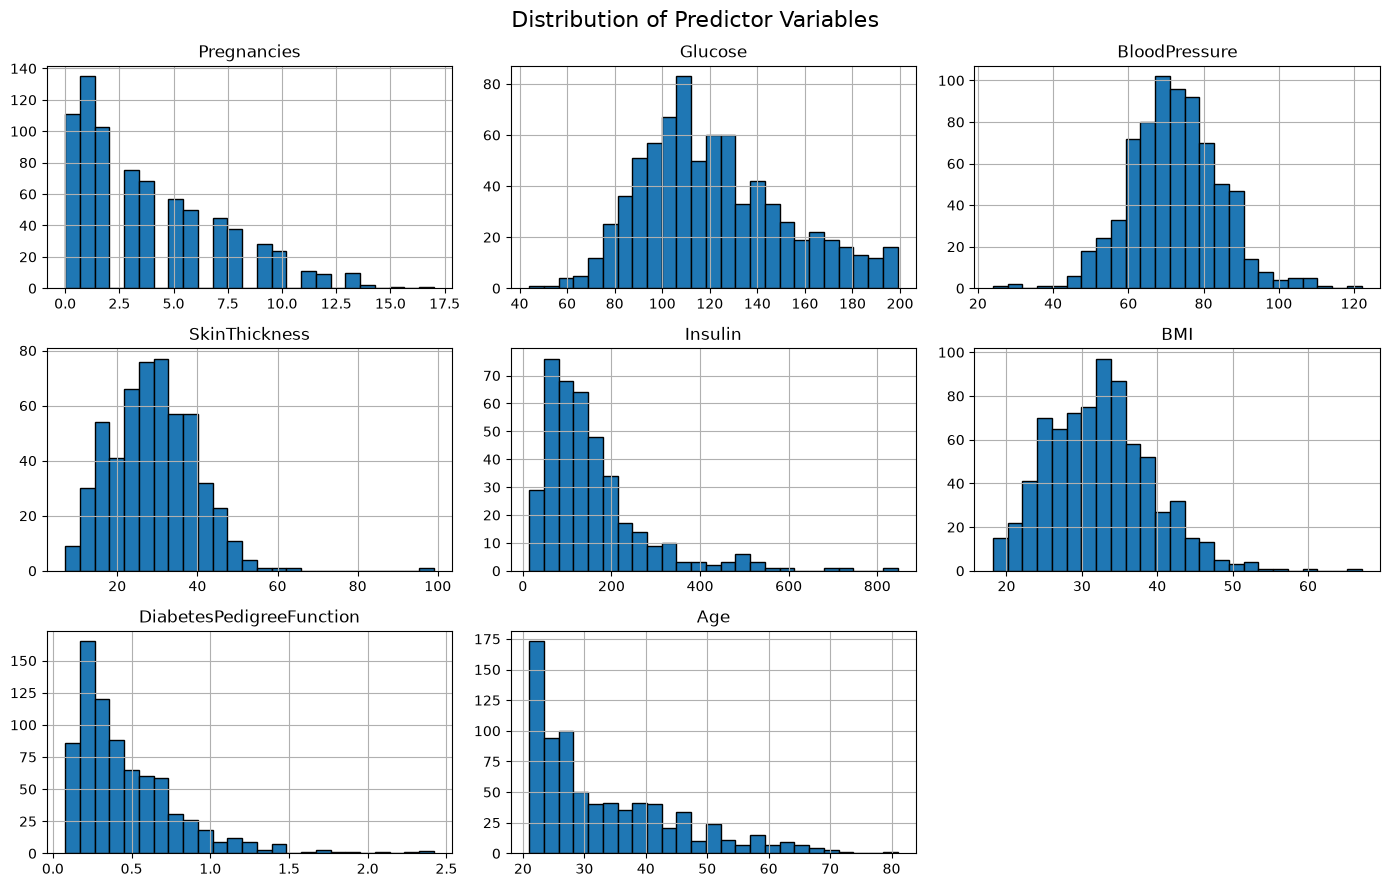

In [13]:
# Visualize predictor distributions

df_model.drop(columns="Outcome").hist(
    figsize=(14, 9),
    bins=25,
    edgecolor="black"
)

plt.suptitle("Distribution of Predictor Variables", fontsize=16)
plt.tight_layout()
plt.show()

## Model preparation

The data will be divided into training and testing sets using a stratified split so that both sets retain approximately the same proportion of outcome classes.

A pipeline will combine:

1. Median imputation learned from the training data
2. Random Forest classification

Feature scaling is unnecessary because decision-tree splits are not based on distances or coefficient magnitudes.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [15]:
# Separate predictors and target

X = df_model.drop(columns="Outcome")
y = df_model["Outcome"]

# Create a stratified 80/20 train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")

print("\nTraining target proportions:")
display(y_train.value_counts(normalize=True).round(3))

print("Testing target proportions:")
display(y_test.value_counts(normalize=True).round(3))

Training set: (614, 8)
Testing set:  (154, 8)

Training target proportions:


Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

Testing target proportions:


Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64

In [16]:
# Build the baseline preprocessing and modeling pipeline

baseline_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or

In [17]:
# Generate baseline predictions

y_pred_baseline = baseline_pipeline.predict(X_test)
y_prob_baseline = baseline_pipeline.predict_proba(X_test)[:, 1]

print("Baseline Random Forest")
print("----------------------")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_baseline):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_baseline):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred_baseline):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_baseline):.3f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred_baseline))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_baseline))

Baseline Random Forest
----------------------
Accuracy:  0.766
Precision: 0.696
Recall:    0.593
F1-score:  0.640
ROC-AUC:   0.821

Classification report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       100
           1       0.70      0.59      0.64        54

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154

Confusion matrix:
[[86 14]
 [22 32]]


### Baseline model interpretation

The baseline Random Forest achieved an accuracy of 0.766 and ROC-AUC of 0.821. Its positive-class precision was 0.696, while recall was 0.593.

The confusion matrix showed:

- 86 true negatives
- 14 false positives
- 22 false negatives
- 32 true positives

The model has useful discriminatory performance, but it failed to identify approximately 41% of the positive cases. Hyperparameter optimization will be performed using cross-validated ROC-AUC rather than test-set accuracy.

In [18]:
from sklearn.model_selection import GridSearchCV

In [19]:
# Define a pipeline for hyperparameter optimization

search_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

# Parameters use model__ because the classifier is named "model" in the pipeline

parameter_grid = {
    "model__max_depth": [2, 4, 6, None],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=search_pipeline,
    param_grid=parameter_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': [None, 'balanced'], 'model__max_depth': [2, 4, ...], 'model__min_samples_leaf': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples

In [20]:
print("Best parameters:")
print(grid_search.best_params_)

print(f"\nBest cross-validated ROC-AUC: {grid_search.best_score_:.3f}")

Best parameters:
{'model__class_weight': None, 'model__max_depth': 6, 'model__min_samples_leaf': 4}

Best cross-validated ROC-AUC: 0.841


In [21]:
optimized_pipeline = grid_search.best_estimator_

y_pred_optimized = optimized_pipeline.predict(X_test)
y_prob_optimized = optimized_pipeline.predict_proba(X_test)[:, 1]

print("Optimized Random Forest")
print("-----------------------")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_optimized):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_optimized):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_optimized):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred_optimized):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_optimized):.3f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred_optimized))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_optimized))

Optimized Random Forest
-----------------------
Accuracy:  0.747
Precision: 0.683
Recall:    0.519
F1-score:  0.589
ROC-AUC:   0.807

Classification report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       100
           1       0.68      0.52      0.59        54

    accuracy                           0.75       154
   macro avg       0.73      0.69      0.70       154
weighted avg       0.74      0.75      0.74       154

Confusion matrix:
[[87 13]
 [26 28]]


In [22]:
from sklearn.compose import ColumnTransformer

In [23]:
# Use the original data containing zero-coded missing measurements

X_raw = df.drop(columns="Outcome")
y = df["Outcome"]

zero_as_missing_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# This transformer replaces zero-coded missing values with training medians.
# All remaining columns pass through unchanged.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "zero_imputer",
            SimpleImputer(
                missing_values=0,
                strategy="median"
            ),
            zero_as_missing_columns
        )
    ],
    remainder="passthrough"
)

deployment_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=4,
        class_weight=None,
        random_state=42
    ))
])

In [24]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

deployment_pipeline.fit(X_train_raw, y_train)

y_pred_deployment = deployment_pipeline.predict(X_test_raw)
y_prob_deployment = deployment_pipeline.predict_proba(X_test_raw)[:, 1]

print("Deployment Pipeline")
print("-------------------")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_deployment):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_deployment):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_deployment):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred_deployment):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_deployment):.3f}")
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_deployment))

Deployment Pipeline
-------------------
Accuracy:  0.740
Precision: 0.675
Recall:    0.500
F1-score:  0.574
ROC-AUC:   0.807

Confusion matrix:
[[87 13]
 [27 27]]


In [25]:
import joblib

In [26]:
# Retrain the final deployment pipeline using all available observations

deployment_pipeline.fit(X_raw, y)

# Save the complete preprocessing and prediction pipeline

model_path = "../models/diabetes_pipeline.pkl"
joblib.dump(deployment_pipeline, model_path)

print(f"Pipeline saved to: {model_path}")

Pipeline saved to: ../models/diabetes_pipeline.pkl


In [27]:
# Reload the saved pipeline

loaded_pipeline = joblib.load("../models/diabetes_pipeline.pkl")

# Test it using one observation

sample_patient = X_raw.iloc[[0]]

sample_prediction = loaded_pipeline.predict(sample_patient)[0]
sample_probability = loaded_pipeline.predict_proba(sample_patient)[0, 1]

print("Sample input:")
display(sample_patient)

print(f"Predicted class: {sample_prediction}")
print(f"Estimated probability: {sample_probability:.3f}")

Sample input:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50


Predicted class: 1
Estimated probability: 0.688


In [28]:
from pathlib import Path

saved_model = Path("../models/diabetes_pipeline.pkl")

print(f"Model exists: {saved_model.exists()}")
print(f"Model size: {saved_model.stat().st_size / 1024:.1f} KB")

Model exists: True
Model size: 1620.7 KB
